# LLM-Based Active Learning
## Author: Hongchen Wang
https://colab.research.google.com/drive/1qgUaTxfDJBPzOvDG44llhvNtW1NIHPM1?usp=sharing

## Import Libraries

In [ ]:
pip install cohere

In [ ]:
import numpy as np
import pandas as pd
import os
import random
import logging
import time
import yaml
import seaborn as sns
import json
import glob
import re
import cohere
import matplotlib.pyplot as plt
from IPython.display import clear_output, display


# ignore warnings
import warnings
warnings.filterwarnings("ignore")

from google.colab import userdata
from openai import OpenAI
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=userdata.get('openrouter_api'),
)
co = cohere.ClientV2(userdata.get('cohere_apiKey'))

## Data preprocessing

In [ ]:
# Import the dataset
dataset_url = "https://raw.githubusercontent.com/Toniaac/MRS2026Spring-AL-SDL-Tutorial/main/LLM-AL/matbench_steels.csv"
df = pd.read_csv(dataset_url)
df.head()

,composition,yield strength,Fe,C,Mn,Si,Cr,Ni,Mo,V,Nb,Co,Al,Ti,N,W
0,Fe0.768C0.000931Mn0.00244Si0.00199Cr0.110Ni0.0...,1167.2,0.768,0.000931,0.002440,0.001990,0.110,0.098100,0.0113,0.000110,0.000060,0.000095,0.004970,0.00269,0.00000,0.0
1,Fe0.648C0.00751Mn0.000103Si0.000201Cr0.158Ni0....,1502.0,0.648,0.007510,0.000103,0.000201,0.158,0.000096,0.0288,0.005310,0.000061,0.149000,0.000836,0.00000,0.00201,0.0
2,Fe0.677C0.00916Mn0.000100Si0.0294Cr0.134Ni0.00...,1382.2,0.677,0.009160,0.000100,0.029400,0.134,0.008810,0.0113,0.000108,0.000474,0.129000,0.000611,0.00000,0.00000,0.0
3,Fe0.679C0.00705Mn0.000103Si0.000201Cr0.153Ni0....,1341.7,0.679,0.007050,0.000103,0.000201,0.153,0.001350,0.0282,0.002330,0.000061,0.128000,0.000628,0.00000,0.00000,0.0
4,Fe0.664C0.00926Mn0.000101Si0.0101Cr0.134Ni0.00...,1322.1,0.664,0.009260,0.000101,0.010100,0.134,0.009000,0.0114,0.000109,0.000479,0.161000,0.000618,0.00000,0.00000,0.0


array([[<Axes: title={'center': 'yield strength'}>,
        <Axes: title={'center': 'Fe'}>, <Axes: title={'center': 'C'}>,
        <Axes: title={'center': 'Mn'}>],
       [<Axes: title={'center': 'Si'}>, <Axes: title={'center': 'Cr'}>,
        <Axes: title={'center': 'Ni'}>, <Axes: title={'center': 'Mo'}>],
       [<Axes: title={'center': 'V'}>, <Axes: title={'center': 'Nb'}>,
        <Axes: title={'center': 'Co'}>, <Axes: title={'center': 'Al'}>],
       [<Axes: title={'center': 'Ti'}>, <Axes: title={'center': 'N'}>,
        <Axes: title={'center': 'W'}>, <Axes: >]], dtype=object)

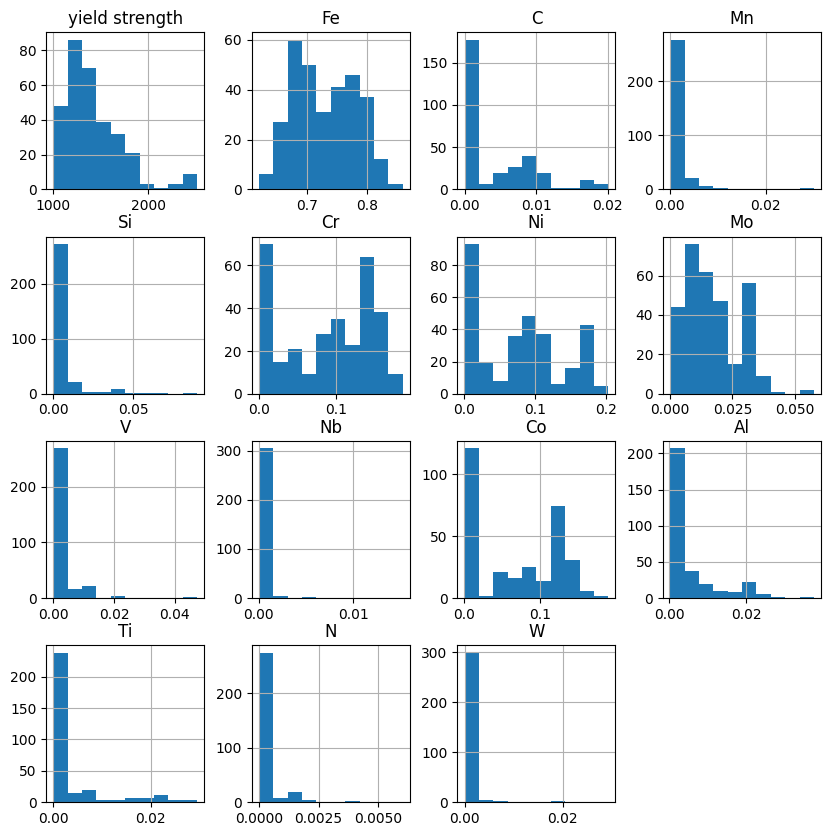

In [ ]:
df.hist(figsize=(10, 10))

In [ ]:
# Systematically generate a column with "column_name: value" format for each row
def generate_formatted_column(row):
    return '; '.join([f"{col}: {row[col]}" for col in row.index[2:]])
df['Formatted_Parameters'] = df.apply(generate_formatted_column, axis=1)

print(df['Formatted_Parameters'][0])
df.head()

Fe: 0.768; C: 0.000931; Mn: 0.00244; Si: 0.00199; Cr: 0.11; Ni: 0.0981; Mo: 0.0113; V: 0.00011; Nb: 6.02e-05; Co: 9.48e-05; Al: 0.00497; Ti: 0.00269; N: 0.0; W: 0.0


,composition,yield strength,Fe,C,Mn,Si,Cr,Ni,Mo,V,Nb,Co,Al,Ti,N,W,Formatted_Parameters
0,Fe0.768C0.000931Mn0.00244Si0.00199Cr0.110Ni0.0...,1167.2,0.768,0.000931,0.002440,0.001990,0.110,0.098100,0.0113,0.000110,0.000060,0.000095,0.004970,0.00269,0.00000,0.0,Fe: 0.768; C: 0.000931; Mn: 0.00244; Si: 0.001...
1,Fe0.648C0.00751Mn0.000103Si0.000201Cr0.158Ni0....,1502.0,0.648,0.007510,0.000103,0.000201,0.158,0.000096,0.0288,0.005310,0.000061,0.149000,0.000836,0.00000,0.00201,0.0,Fe: 0.648; C: 0.00751; Mn: 0.000103; Si: 0.000...
2,Fe0.677C0.00916Mn0.000100Si0.0294Cr0.134Ni0.00...,1382.2,0.677,0.009160,0.000100,0.029400,0.134,0.008810,0.0113,0.000108,0.000474,0.129000,0.000611,0.00000,0.00000,0.0,Fe: 0.677; C: 0.00916; Mn: 0.0001; Si: 0.0294;...
3,Fe0.679C0.00705Mn0.000103Si0.000201Cr0.153Ni0....,1341.7,0.679,0.007050,0.000103,0.000201,0.153,0.001350,0.0282,0.002330,0.000061,0.128000,0.000628,0.00000,0.00000,0.0,Fe: 0.679; C: 0.00705; Mn: 0.000103; Si: 0.000...
4,Fe0.664C0.00926Mn0.000101Si0.0101Cr0.134Ni0.00...,1322.1,0.664,0.009260,0.000101,0.010100,0.134,0.009000,0.0114,0.000109,0.000479,0.161000,0.000618,0.00000,0.00000,0.0,Fe: 0.664; C: 0.00926; Mn: 0.000101; Si: 0.010...


In [ ]:
# Pair the features with observations
df['Formatted_Parameters with output'] = df.apply(lambda row: f"Parameters: {row['Formatted_Parameters']}" + f" \n\n**The Actual Yield Strength is {round(row['yield strength'], 2)} MPa**", axis=1)
df.head()

,composition,yield strength,Fe,C,Mn,Si,Cr,Ni,Mo,V,Nb,Co,Al,Ti,N,W,Formatted_Parameters,Formatted_Parameters with output
0,Fe0.768C0.000931Mn0.00244Si0.00199Cr0.110Ni0.0...,1167.2,0.768,0.000931,0.002440,0.001990,0.110,0.098100,0.0113,0.000110,0.000060,0.000095,0.004970,0.00269,0.00000,0.0,Fe: 0.768; C: 0.000931; Mn: 0.00244; Si: 0.001...,Parameters: Fe: 0.768; C: 0.000931; Mn: 0.0024...
1,Fe0.648C0.00751Mn0.000103Si0.000201Cr0.158Ni0....,1502.0,0.648,0.007510,0.000103,0.000201,0.158,0.000096,0.0288,0.005310,0.000061,0.149000,0.000836,0.00000,0.00201,0.0,Fe: 0.648; C: 0.00751; Mn: 0.000103; Si: 0.000...,Parameters: Fe: 0.648; C: 0.00751; Mn: 0.00010...
2,Fe0.677C0.00916Mn0.000100Si0.0294Cr0.134Ni0.00...,1382.2,0.677,0.009160,0.000100,0.029400,0.134,0.008810,0.0113,0.000108,0.000474,0.129000,0.000611,0.00000,0.00000,0.0,Fe: 0.677; C: 0.00916; Mn: 0.0001; Si: 0.0294;...,Parameters: Fe: 0.677; C: 0.00916; Mn: 0.0001;...
3,Fe0.679C0.00705Mn0.000103Si0.000201Cr0.153Ni0....,1341.7,0.679,0.007050,0.000103,0.000201,0.153,0.001350,0.0282,0.002330,0.000061,0.128000,0.000628,0.00000,0.00000,0.0,Fe: 0.679; C: 0.00705; Mn: 0.000103; Si: 0.000...,Parameters: Fe: 0.679; C: 0.00705; Mn: 0.00010...
4,Fe0.664C0.00926Mn0.000101Si0.0101Cr0.134Ni0.00...,1322.1,0.664,0.009260,0.000101,0.010100,0.134,0.009000,0.0114,0.000109,0.000479,0.161000,0.000618,0.00000,0.00000,0.0,Fe: 0.664; C: 0.00926; Mn: 0.000101; Si: 0.010...,Parameters: Fe: 0.664; C: 0.00926; Mn: 0.00010...


## Proposing an experiment

In [ ]:
# Specify optimization range
elements = ['Fe', 'C', 'Mn', 'Si', 'Cr', 'Ni', 'Mo', 'V', 'Nb', 'Co', 'Al', 'Ti', 'N', 'W']

# Calculate min and max for each element
element_ranges = {
    elem: (df[elem].min(), df[elem].max()) for elem in elements
}

# Generate a sentence summarizing the ranges
ranges = "; ".join(
    [f"{elem} ranges from {min_val:.6f} to {max_val:.6f}" for elem, (min_val, max_val) in element_ranges.items()]
) + "."
ranges

'Fe ranges from 0.620000 to 0.860000; C ranges from 0.000000 to 0.020100; Mn ranges from 0.000099 to 0.030000; Si ranges from 0.000197 to 0.089900; Cr ranges from 0.000102 to 0.186000; Ni ranges from 0.000095 to 0.203000; Mo ranges from 0.000111 to 0.057600; V ranges from 0.000000 to 0.047400; Nb ranges from 0.000000 to 0.015200; Co ranges from 0.000090 to 0.190000; Al ranges from 0.000208 to 0.037600; Ti ranges from 0.000000 to 0.029500; N ranges from 0.000000 to 0.006020; W ranges from 0.000000 to 0.029300.'

In [ ]:
def LLM_AL(observations_str, ranges, Model="anthropic/claude-4.6-sonnet", Temperature=0, sleep=0.1):
    response = client.chat.completions.create(
        model=Model,
        messages=[
            {"role": "system", "content":
                f"You are helping to find steel compositions that maximize yield strength. "
                f"Based on the following previous experimental reports, suggest the next composition to test. "
                f"Only suggest steel compositions within these element ranges: {ranges}. "
                f"Do not include any elements not listed or values outside these ranges."
                f"Output format should be 'Fe: *; C: *; Mn: *; Si: *; Cr: *; Ni: *; Mo: *; V: *; Nb: *; Co: *; Al: *' surrounded by curly brackets"
            },
            {"role": "user", "content": f'\nPrior Observations: {observations_str}'}
        ],
        temperature=Temperature
    )
    time.sleep(sleep)
    return response.choices[0].message.content

In [ ]:
sample_data = df['Formatted_Parameters with output'][0]
sample_suggestion = LLM_AL(sample_data, ranges)
print(sample_data)
print("\n\n\n")
print(sample_suggestion)

Parameters: Fe: 0.768; C: 0.000931; Mn: 0.00244; Si: 0.00199; Cr: 0.11; Ni: 0.0981; Mo: 0.0113; V: 0.00011; Nb: 6.02e-05; Co: 9.48e-05; Al: 0.00497; Ti: 0.00269; N: 0.0; W: 0.0 

**The Actual Yield Strength is 1167.2 MPa**




I'll analyze the previous observation and suggest a composition to maximize yield strength.

**Analysis of current composition:**
- Yield strength of 1167.2 MPa with a maraging/martensitic-type steel
- The composition has moderate Cr (11%), moderate Ni (~9.8%), low Co (~0.009%), low Mo (~1.1%)
- Co, Mo, and Ni are key strengthening elements in maraging steels
- Al and Ti contribute to precipitation hardening

**Strategy to increase yield strength:**
- Increase Co significantly (major strengthener in maraging steels, up to allowed max ~19%)
- Increase Mo (precipitation hardening via Mo-rich precipitates)
- Increase Ni (austenite stabilizer, contributes to martensite strength)
- Increase Ti (precipitation hardening via Ni₃Ti)
- Increase Al (precipitation hardening)

## Similarity comparison (only for benchmarking)

In [ ]:
re.search(r'\{.*?\}', sample_suggestion).group(0)

'{Fe: 0.726; C: 0.0001; Mn: 0.001; Si: 0.005; Cr: 0.100; Ni: 0.203; Mo: 0.0576; V: 0.040; Nb: 0.010; Co: 0.190; Al: 0.0376}'

In [ ]:
def similarity_compare(suggestion, doc):
  match = re.search(r'\{.*?\}', sample_suggestion).group(0)
  query = f"Which of the following experiment matches best with the suggestion? \nSuggestion: {match}"
  results = co.rerank(model="rerank-v3.5", query=query, documents=docs, top_n=1)
  return results

In [ ]:
docs = list(df['Formatted_Parameters'])
best_match = similarity_compare(re.search(r'\{.*?\}', sample_suggestion).group(0), docs)
best_match

V2RerankResponse(id='93f38996-acec-4555-89ec-5302d48604c5', results=[V2RerankResponseResultsItem(index=298, relevance_score=0.7038554)], meta=ApiMeta(api_version=ApiMetaApiVersion(version='2', is_deprecated=None, is_experimental=None), billed_units=ApiMetaBilledUnits(images=None, input_tokens=None, image_tokens=None, output_tokens=None, search_units=4.0, classifications=None), tokens=None, cached_tokens=None, warnings=None))

In [ ]:
docs[best_match.results[0].index]

'Fe: 0.721; C: 0.000476; Mn: 0.000104; Si: 0.000203; Cr: 0.056; Ni: 0.109; Mo: 0.0304; V: 0.0105; Nb: 6.15e-05; Co: 0.0611; Al: 0.00191; Ti: 0.00931; N: 0.0; W: 0.0'

## Active Learning (benchmarking or campaign)

In [ ]:
def run_experiment(df, ranges, random_seed=42, run=1,
                   model="anthropic/claude-4.6-sonnet",
                   temperature=0.0, sleep=0.1):

    random.seed(random_seed)

    list_of_observations = []
    list_of_strength = []
    trajectory_data = []

    data_copy = df.copy()
    max_strength = data_copy['yield strength'].max()

    initial_idx = random.choice(data_copy.index)
    print(f"Initial observation: Experiment {initial_idx}")

    list_of_observations.append(data_copy.loc[initial_idx, 'Formatted_Parameters with output'])
    list_of_strength.append(data_copy.loc[initial_idx, 'yield strength'])

    trajectory_data.append({
        "Iteration": 0,
        "Experiment Index": initial_idx,
        "Selected Parameters": data_copy.loc[initial_idx, 'Formatted_Parameters'],
        "Suggested Parameters": "N/A",
        "Suggestion": "N/A",
        "Observed Yield Strength": data_copy.loc[initial_idx, 'yield strength'],
        "Max Yield Strength in Dataset": max_strength,
        "Stopping Reason": "Initial selection"
    })

    data_copy = data_copy.drop(index=initial_idx)

    for i in range(len(data_copy)):
        observations_str = ' '.join(list_of_observations)
        suggestion = LLM_AL(observations_str, ranges)
        suggested_parameters = re.search(r'\{.*?\}', suggestion).group(0)
        query = f"Which of the following experiment matches best with the suggestion? \nSuggestion: {suggested_parameters}"

        docs = list(data_copy['Formatted_Parameters'])
        results = co.rerank(model="rerank-v3.5", query=query, documents=docs, top_n=1)

        best_idx = results.results[0].index
        best_experiment = data_copy.iloc[best_idx]
        best_strength = best_experiment['yield strength']

        trajectory_data.append({
            "Iteration": i + 1,
            "Experiment Index": best_experiment.name,
            "Selected Parameters": best_experiment['Formatted_Parameters'],
            "Suggested Parameters": suggested_parameters,
            "Suggestion": suggestion,
            "Observed Yield Strength": best_strength,
            "Max Yield Strength in Dataset": max_strength,
            "Stopping Reason": "Max yield strength reached" if best_strength >= max_strength else "Continuing"
        })

        list_of_observations.append(best_experiment['Formatted_Parameters with output'])
        list_of_strength.append(best_strength)
        data_copy = data_copy.drop(data_copy.index[best_idx])

        # Redraw output in-place
        clear_output(wait=True)

        # Plot first so it stays visually at the top
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(range(1, len(list_of_strength) + 1), list_of_strength, marker='o', linestyle='-')
        ax.axhline(y=max_strength*0.9, color='g', linestyle='--', label='Top 10%')
        ax.axhline(y=max_strength, color='r', linestyle='--', label='Max Yield Strength')
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Yield Strength")
        ax.set_title(f"Yield Strength Trajectory with Random Seed {random_seed}")
        ax.legend()
        ax.grid(True)
        display(fig)
        plt.close(fig)

        # Then print progress underneath
        print(f"Initial observation: Experiment {initial_idx}")
        print(f"Iteration {i+1}: Added new observation (Experiment {best_experiment.name})")
        print(f"Suggestion: {suggestion}")
        print(f"Yield Strength: {best_strength}\n")

        if best_strength >= max_strength:
            print(f"Stopping early at iteration {i+1} - Max yield strength found.")
            break

        time.sleep(sleep)

    trajectory_df = pd.DataFrame(trajectory_data)
    filename = f"llm_experiment_yield_strength_trajectory_parameters_seed{random_seed}_run{run}.csv"
    trajectory_df.to_csv(filename, index=False)

    return trajectory_df

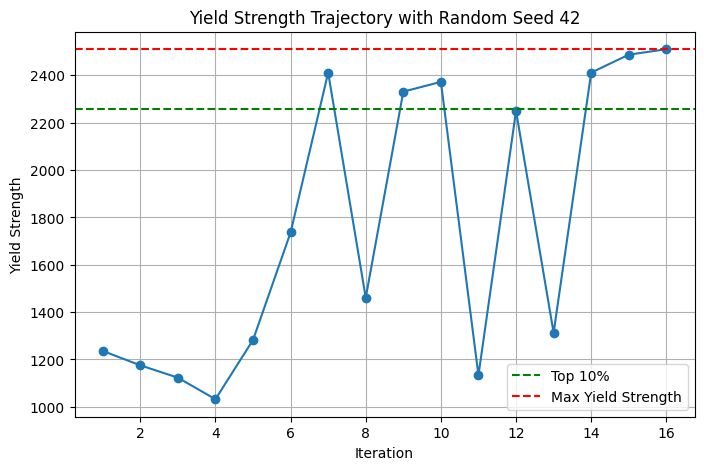

Initial observation: Experiment 57
Iteration 15: Added new observation (Experiment 306)
Suggestion: I'll analyze the patterns from the high-performing compositions to identify what drives maximum yield strength.

Key observations from top performers (>2300 MPa):
- Fe: 0.620-0.665 (lower Fe content)
- Ni: 0.168-0.192 (high Ni)
- Co: 0.119-0.146 (high Co)
- Mo: 0.017-0.024 (moderate Mo)
- Ti: 0.018-0.022 (moderate Ti)
- Cr: very low (~0.00011)
- C: very low (~0.0005)
- Al: low-moderate (~0.002-0.005)

The best result (2487.3 MPa) had:
- Fe: 0.634, Ni: 0.173, Co: 0.146, Mo: 0.0237, Ti: 0.0176, Al: 0.00277

I'll push toward the optimal region: maximize Ni (closer to 0.203), keep Co high (~0.150), moderate Mo (~0.025), Ti (~0.022), minimize Cr, keep C low, and adjust Fe accordingly.

Let me calculate: Ni=0.195, Co=0.155, Mo=0.025, Ti=0.022, Al=0.003, Si=0.001, Mn=0.0005, C=0.0005, Cr=0.00011, Nb=0.00006, V=0.00011
Sum of non-Fe = 0.195+0.155+0.025+0.022+0.003+0.001+0.0005+0.0005+0.00011+0.0

,Iteration,Experiment Index,Selected Parameters,Suggested Parameters,Suggestion,Observed Yield Strength,Max Yield Strength in Dataset,Stopping Reason
0,0,57,Fe: 0.763; C: 0.00479; Mn: 0.00524; Si: 0.0061...,N/A,N/A,1235.9,2510.3,Initial selection
1,1,85,Fe: 0.767; C: 0.000465; Mn: 0.00112; Si: 0.003...,{Fe: 0.777; C: 0.002; Mn: 0.001; Si: 0.002; Cr...,I'll analyze the previous observation and sugg...,1175.4,2510.3,Continuing
2,2,293,Fe: 0.727; C: 0.000476; Mn: 0.000104; Si: 0.00...,{Fe: 0.727; C: 0.010; Mn: 0.003; Si: 0.008; Cr...,I'll analyze the two previous observations to ...,1123.1,2510.3,Continuing
3,3,104,Fe: 0.774; C: 0.0; Mn: 0.000511; Si: 0.000599;...,{Fe: 0.740; C: 0.0095; Mn: 0.00524; Si: 0.0061...,I'll analyze the previous observations to iden...,1032.1,2510.3,Continuing
4,4,134,Fe: 0.711; C: 0.00931; Mn: 0.000102; Si: 0.000...,{Fe: 0.711; C: 0.00500; Mn: 0.00500; Si: 0.006...,I'll analyze the previous experimental data to...,1282.2,2510.3,Continuing
5,5,147,Fe: 0.625; C: 0.0; Mn: 0.000102; Si: 0.0002; C...,{Fe: 0.635; C: 0.012; Mn: 0.005; Si: 0.005; Cr...,I'll analyze the previous observations to iden...,1736.3,2510.3,Continuing
6,6,191,Fe: 0.62; C: 0.000953; Mn: 0.000521; Si: 0.001...,{Fe: 0.620; C: 0.001; Mn: 0.001; Si: 0.001; Cr...,I'll analyze the previous observations to iden...,2411.5,2510.3,Continuing
7,7,249,Fe: 0.656; C: 0.00758; Mn: 0.000104; Si: 0.000...,{Fe: 0.621; C: 0.0005; Mn: 0.001; Si: 0.0002; ...,I'll analyze the patterns from the previous ex...,1460.7,2510.3,Continuing
8,8,206,Fe: 0.652; C: 0.0; Mn: 0.000522; Si: 0.00102; ...,{Fe: 0.620; C: 0.001; Mn: 0.0001; Si: 0.001; C...,I'll analyze the previous experiments to ident...,2331.1,2510.3,Continuing
9,9,292,Fe: 0.662; C: 0.000477; Mn: 0.000521; Si: 0.00...,{Fe: 0.620; C: 0.0005; Mn: 0.0001; Si: 0.001; ...,I'll analyze the patterns from the experimenta...,2372.4,2510.3,Continuing


In [ ]:
run_experiment(df, ranges, random_seed=42, run = 1)